# EE 451: Communications Systems
## Lesson 10 - Exam Review & Angle Modulation

### Learning Objectives
By the end of this lesson, you will be able to:
- Distinguish between frequency modulation (FM) and phase modulation (PM)
- Explain the relationship between FM and PM through differentiation/integration
- Define frequency deviation and modulation index for FM
- Distinguish between narrowband FM (NBFM) and wideband FM (WBFM)
- Calculate instantaneous frequency for FM signals

### Textbook Reference
Haykin & Moher, Chapter 4.1-4.5

In [1]:
# Setup: Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# Use consistent plot style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

print("Setup complete! NumPy version:", np.__version__)

Setup complete! NumPy version: 2.4.1


## Part 1: Angle Modulation Concept

**Carrier:** $c(t) = A_c \cos(2\pi f_c t + \phi_c)$ has three parameters: amplitude, frequency, phase

**Amplitude Modulation (AM):** Vary $A_c$ with message — information in envelope

**Angle Modulation:** Vary phase or frequency — information in angle
- **Phase Modulation (PM):** $\phi(t) = k_p m(t)$
- **Frequency Modulation (FM):** $f_i(t) = f_c + k_f m(t)$

Key difference from AM: **constant envelope** (amplitude stays at $A_c$)

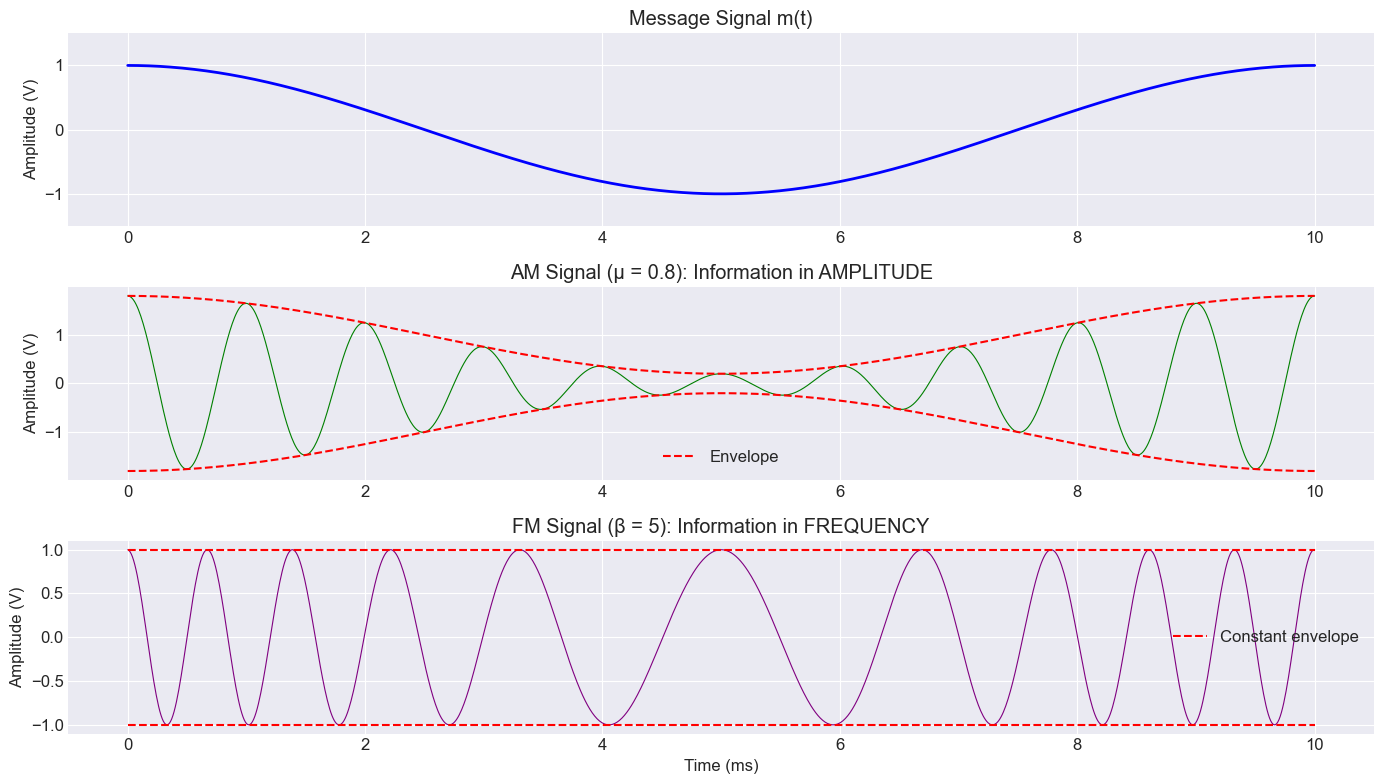

AM vs FM Comparison
AM: Envelope varies, frequency constant at 1000 Hz
FM: Envelope constant at 1.0 V, frequency varies
    Instantaneous freq range: [500, 1500] Hz


In [2]:
# Part 1: AM vs FM - Visual Comparison

# Parameters
fs = 100000  # Sampling rate (Hz)
t = np.linspace(0, 0.01, int(fs * 0.01))  # 10 ms
fc = 1000    # Carrier frequency (Hz)
fm = 100     # Message frequency (Hz)
Ac = 1.0     # Carrier amplitude

# Message signal
m = np.cos(2 * np.pi * fm * t)

# AM signal (mu = 0.8)
mu = 0.8
s_am = Ac * (1 + mu * m) * np.cos(2 * np.pi * fc * t)

# FM signal (beta = 5)
kf = 500  # Hz/V
beta = kf / fm  # = 5
phase_fm = 2 * np.pi * kf * np.cumsum(m) / fs
s_fm = Ac * np.cos(2 * np.pi * fc * t + phase_fm)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Message
axes[0].plot(t * 1000, m, 'b-', linewidth=2)
axes[0].set_ylabel('Amplitude (V)')
axes[0].set_title('Message Signal m(t)')
axes[0].set_ylim(-1.5, 1.5)

# AM
axes[1].plot(t * 1000, s_am, 'g-', linewidth=0.8)
axes[1].plot(t * 1000, Ac * (1 + mu * m), 'r--', linewidth=1.5, label='Envelope')
axes[1].plot(t * 1000, -Ac * (1 + mu * m), 'r--', linewidth=1.5)
axes[1].set_ylabel('Amplitude (V)')
axes[1].set_title(f'AM Signal (\u03bc = {mu}): Information in AMPLITUDE')
axes[1].legend()

# FM
axes[2].plot(t * 1000, s_fm, 'purple', linewidth=0.8)
axes[2].plot(t * 1000, Ac * np.ones_like(t), 'r--', linewidth=1.5, label='Constant envelope')
axes[2].plot(t * 1000, -Ac * np.ones_like(t), 'r--', linewidth=1.5)
axes[2].set_ylabel('Amplitude (V)')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title(f'FM Signal (\u03b2 = {beta:.0f}): Information in FREQUENCY')
axes[2].legend()

plt.tight_layout()
plt.show()

print("=" * 55)
print("AM vs FM Comparison")
print("=" * 55)
print(f"AM: Envelope varies, frequency constant at {fc} Hz")
print(f"FM: Envelope constant at {Ac} V, frequency varies")
print(f"    Instantaneous freq range: [{fc - kf:.0f}, {fc + kf:.0f}] Hz")

## Part 2: FM Signal Generation

**FM Signal:** $s(t) = A_c \cos\left[2\pi f_c t + 2\pi k_f \int_0^t m(\tau) d\tau\right]$

**Instantaneous frequency:** $f_i(t) = f_c + k_f m(t)$
- $k_f$: Frequency sensitivity (Hz/V)
- $\Delta f = k_f \cdot \max|m(t)|$: Maximum frequency deviation

**Modulation index:** $\beta = \frac{\Delta f}{f_m}$ (for sinusoidal message at frequency $f_m$)

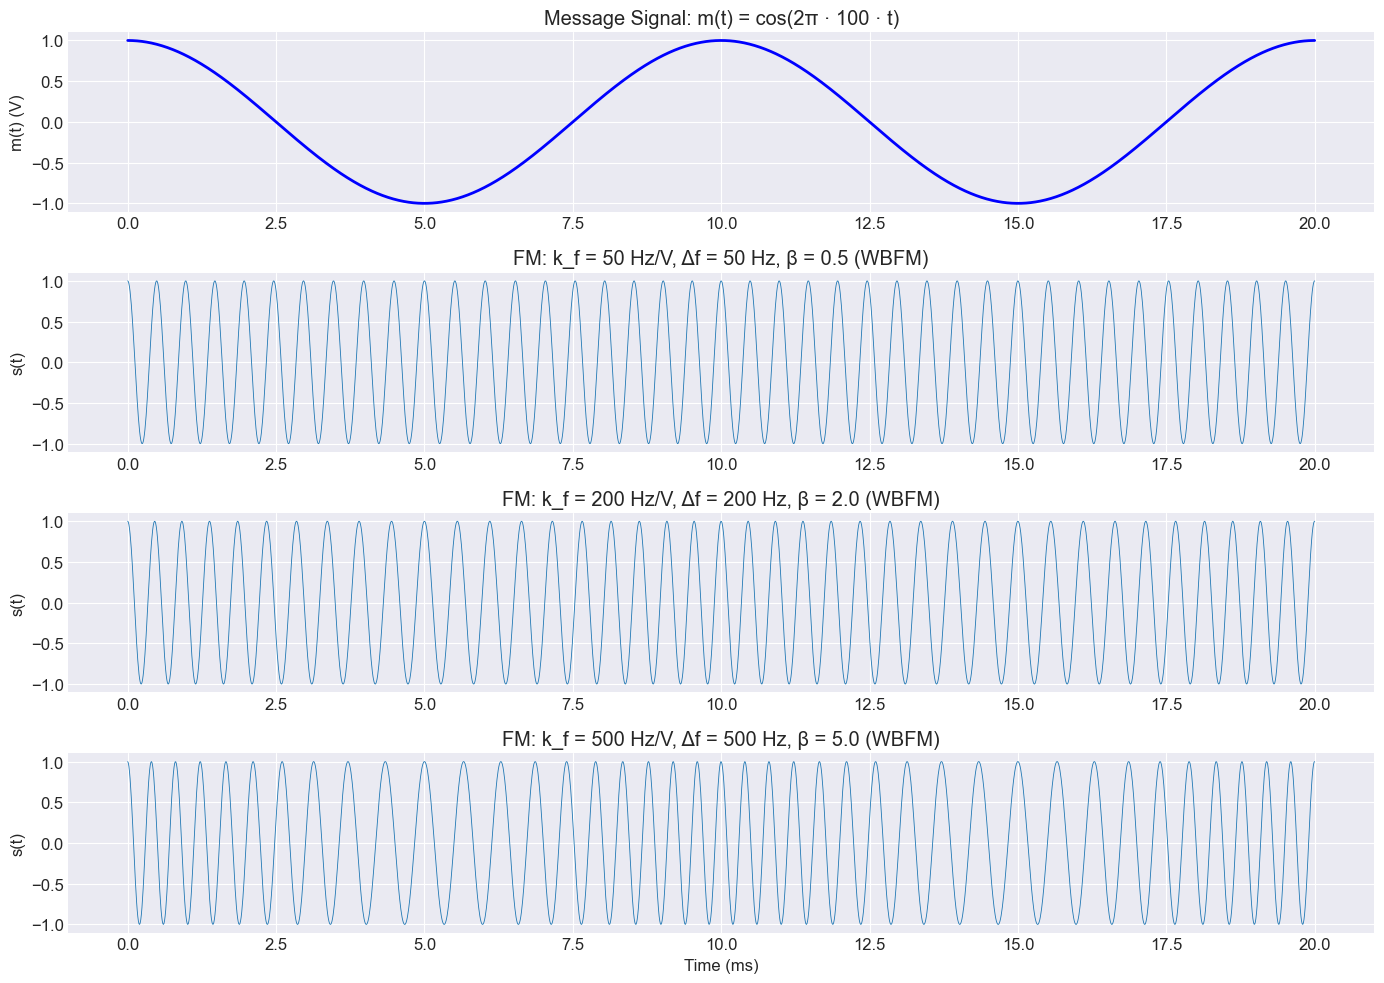

FM Modulation Index Examples
Carrier: fc = 2000 Hz, Message: fm = 100 Hz

  kf = 50 Hz/V:
    Delta_f = 50 Hz
    beta = 0.5
    f_i range: [1950, 2050] Hz
    Type: WBFM

  kf = 200 Hz/V:
    Delta_f = 200 Hz
    beta = 2.0
    f_i range: [1800, 2200] Hz
    Type: WBFM

  kf = 500 Hz/V:
    Delta_f = 500 Hz
    beta = 5.0
    f_i range: [1500, 2500] Hz
    Type: WBFM


In [3]:
# Part 2: FM Signal - Instantaneous Frequency Visualization

fs = 100000
t = np.linspace(0, 0.02, int(fs * 0.02))  # 20 ms
fc = 2000
fm = 100
Ac = 1.0

# Message
m = np.cos(2 * np.pi * fm * t)

# FM with different kf values
kf_values = [50, 200, 500]  # Hz/V

fig, axes = plt.subplots(len(kf_values) + 1, 1, figsize=(14, 10))

# Message signal
axes[0].plot(t * 1000, m, 'b-', linewidth=2)
axes[0].set_ylabel('m(t) (V)')
axes[0].set_title('Message Signal: m(t) = cos(2\u03c0 \u00b7 100 \u00b7 t)')

for i, kf in enumerate(kf_values):
    beta = kf / fm
    delta_f = kf  # max|m(t)| = 1
    
    # Generate FM signal
    phase = 2 * np.pi * kf * np.cumsum(m) / fs
    s_fm = Ac * np.cos(2 * np.pi * fc * t + phase)
    
    ax = axes[i + 1]
    ax.plot(t * 1000, s_fm, linewidth=0.6)
    ax.set_ylabel('s(t)')
    ax.set_title(f'FM: k_f = {kf} Hz/V, \u0394f = {delta_f} Hz, '
                 f'\u03b2 = {beta:.1f} ({"NBFM" if beta < 0.3 else "WBFM"})')

axes[-1].set_xlabel('Time (ms)')
plt.tight_layout()
plt.show()

print("=" * 55)
print("FM Modulation Index Examples")
print("=" * 55)
print(f"Carrier: fc = {fc} Hz, Message: fm = {fm} Hz")
for kf in kf_values:
    beta = kf / fm
    print(f"\n  kf = {kf} Hz/V:")
    print(f"    Delta_f = {kf} Hz")
    print(f"    beta = {beta:.1f}")
    print(f"    f_i range: [{fc - kf}, {fc + kf}] Hz")
    print(f"    Type: {'NBFM' if beta < 0.3 else 'WBFM'}")

## Part 3: FM vs PM Comparison

**Phase Modulation (PM):** $s(t) = A_c \cos[2\pi f_c t + k_p m(t)]$
- Phase proportional to $m(t)$
- $k_p$: Phase sensitivity (rad/V)

**Frequency Modulation (FM):** $s(t) = A_c \cos\left[2\pi f_c t + 2\pi k_f \int m(\tau) d\tau\right]$
- Phase proportional to $\int m(t)$
- FM is PM with integrated message
- PM is FM with differentiated message

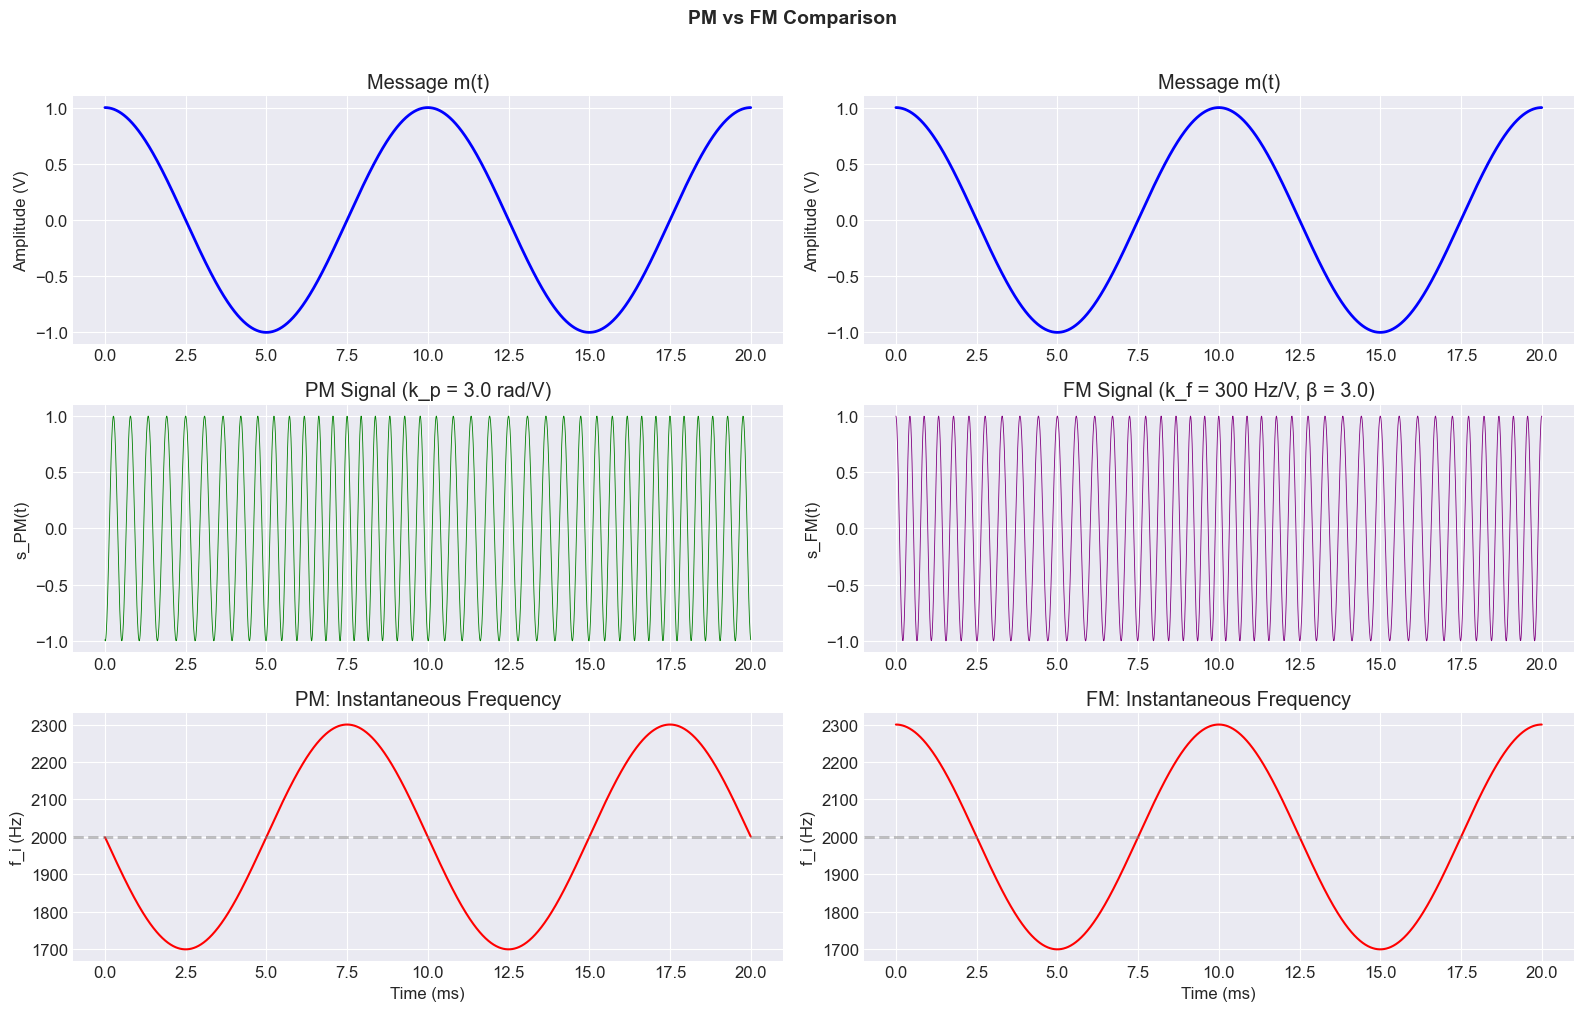

FM vs PM Comparison

PM: Phase directly proportional to m(t)
    Instantaneous freq proportional to dm/dt
FM: Phase proportional to integral of m(t)
    Instantaneous freq directly proportional to m(t)

Relationship: FM = PM with integrated message


In [4]:
# Part 3: FM vs PM for the Same Message

fs = 100000
t = np.linspace(0, 0.02, int(fs * 0.02))
fc = 2000
fm = 100

# Message
m = np.cos(2 * np.pi * fm * t)

# PM signal: phase = kp * m(t)
kp = 3.0  # rad/V
phase_pm = kp * m
s_pm = np.cos(2 * np.pi * fc * t + phase_pm)

# FM signal: phase = 2*pi*kf * integral(m(t))
kf = 300  # Hz/V
beta = kf / fm
phase_fm = 2 * np.pi * kf * np.cumsum(m) / fs
s_fm = np.cos(2 * np.pi * fc * t + phase_fm)

# Instantaneous frequencies
fi_pm = fc + np.gradient(phase_pm, 1/fs) / (2 * np.pi)
fi_fm = fc + kf * m

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# Left column: PM
axes[0, 0].plot(t * 1000, m, 'b-', linewidth=2)
axes[0, 0].set_title('Message m(t)')
axes[0, 0].set_ylabel('Amplitude (V)')

axes[1, 0].plot(t * 1000, s_pm, 'g-', linewidth=0.6)
axes[1, 0].set_title(f'PM Signal (k_p = {kp} rad/V)')
axes[1, 0].set_ylabel('s_PM(t)')

axes[2, 0].plot(t * 1000, fi_pm, 'r-', linewidth=1.5)
axes[2, 0].axhline(y=fc, color='gray', linestyle='--', alpha=0.5)
axes[2, 0].set_title('PM: Instantaneous Frequency')
axes[2, 0].set_ylabel('f_i (Hz)')
axes[2, 0].set_xlabel('Time (ms)')

# Right column: FM
axes[0, 1].plot(t * 1000, m, 'b-', linewidth=2)
axes[0, 1].set_title('Message m(t)')
axes[0, 1].set_ylabel('Amplitude (V)')

axes[1, 1].plot(t * 1000, s_fm, 'purple', linewidth=0.6)
axes[1, 1].set_title(f'FM Signal (k_f = {kf} Hz/V, \u03b2 = {beta:.1f})')
axes[1, 1].set_ylabel('s_FM(t)')

axes[2, 1].plot(t * 1000, fi_fm, 'r-', linewidth=1.5)
axes[2, 1].axhline(y=fc, color='gray', linestyle='--', alpha=0.5)
axes[2, 1].set_title('FM: Instantaneous Frequency')
axes[2, 1].set_ylabel('f_i (Hz)')
axes[2, 1].set_xlabel('Time (ms)')

plt.suptitle('PM vs FM Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("=" * 55)
print("FM vs PM Comparison")
print("=" * 55)
print(f"\nPM: Phase directly proportional to m(t)")
print(f"    Instantaneous freq proportional to dm/dt")
print(f"FM: Phase proportional to integral of m(t)")
print(f"    Instantaneous freq directly proportional to m(t)")
print(f"\nRelationship: FM = PM with integrated message")

## Part 4: Instantaneous Frequency

**Definition:** $f_i(t) = f_c + k_f m(t)$

The instantaneous frequency swings between:
- Maximum: $f_c + \Delta f$ when $m(t) = +\max$
- Minimum: $f_c - \Delta f$ when $m(t) = -\max$

**Frequency deviation:** $\Delta f = k_f \cdot \max|m(t)|$

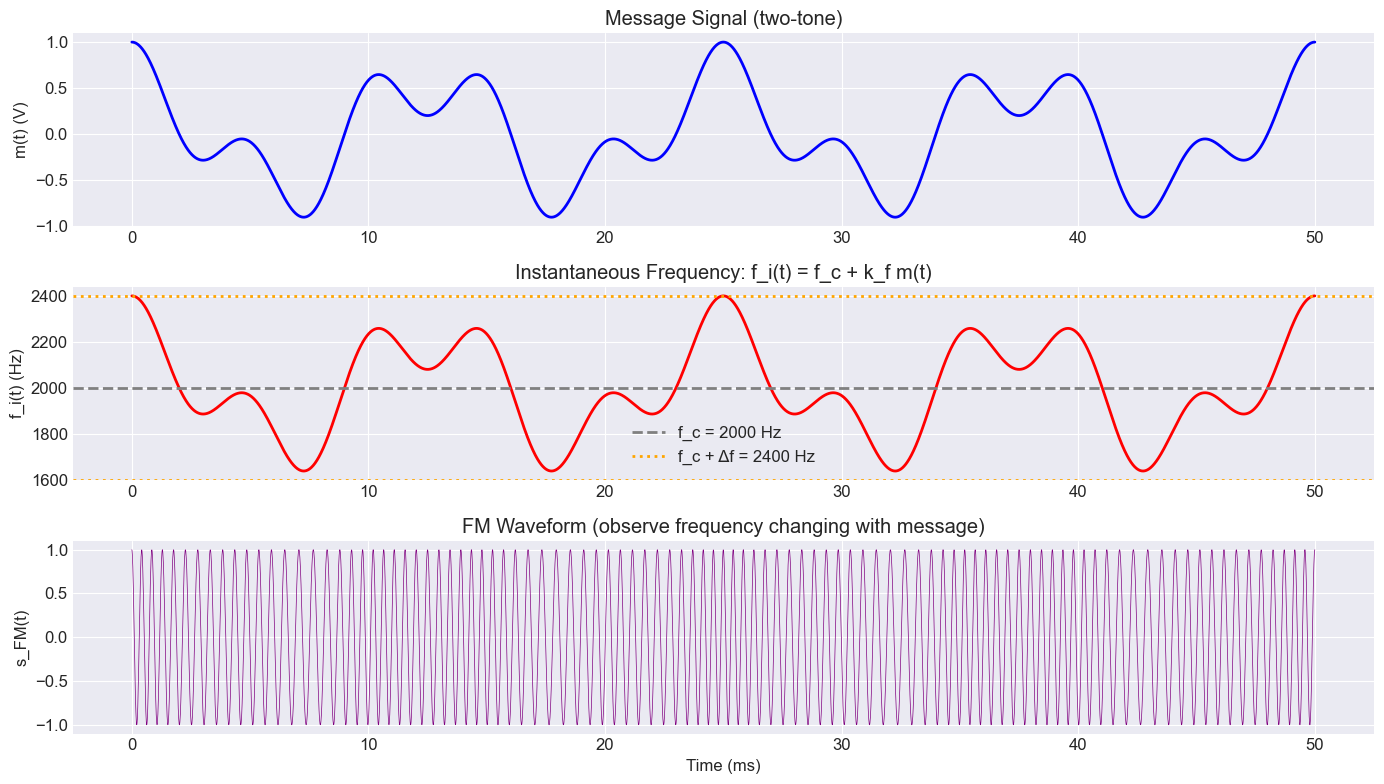

Instantaneous Frequency
Carrier: fc = 2000 Hz
Frequency sensitivity: kf = 400 Hz/V
Frequency deviation: Delta_f = 400 Hz
Freq range: [1600, 2400] Hz


In [5]:
# Part 4: Instantaneous Frequency Visualization

fs = 100000
t = np.linspace(0, 0.05, int(fs * 0.05))  # 50 ms
fc = 2000

# Complex (non-sinusoidal) message for a richer example
m = 0.6 * np.cos(2 * np.pi * 80 * t) + 0.4 * np.cos(2 * np.pi * 200 * t)
m = m / np.max(np.abs(m))  # Normalize to [-1, 1]

kf = 400  # Hz/V
delta_f = kf * np.max(np.abs(m))

# Instantaneous frequency
fi = fc + kf * m

# FM signal
phase = 2 * np.pi * kf * np.cumsum(m) / fs
s_fm = np.cos(2 * np.pi * fc * t + phase)

fig, axes = plt.subplots(3, 1, figsize=(14, 8))

# Message
axes[0].plot(t * 1000, m, 'b-', linewidth=2)
axes[0].set_ylabel('m(t) (V)')
axes[0].set_title('Message Signal (two-tone)')

# Instantaneous frequency
axes[1].plot(t * 1000, fi, 'r-', linewidth=2)
axes[1].axhline(y=fc, color='gray', linestyle='--', label=f'f_c = {fc} Hz')
axes[1].axhline(y=fc + delta_f, color='orange', linestyle=':', 
                label=f'f_c + \u0394f = {fc + delta_f:.0f} Hz')
axes[1].axhline(y=fc - delta_f, color='orange', linestyle=':')
axes[1].set_ylabel('f_i(t) (Hz)')
axes[1].set_title('Instantaneous Frequency: f_i(t) = f_c + k_f m(t)')
axes[1].legend()

# FM waveform
axes[2].plot(t * 1000, s_fm, 'purple', linewidth=0.5)
axes[2].set_ylabel('s_FM(t)')
axes[2].set_xlabel('Time (ms)')
axes[2].set_title('FM Waveform (observe frequency changing with message)')

plt.tight_layout()
plt.show()

print("=" * 55)
print("Instantaneous Frequency")
print("=" * 55)
print(f"Carrier: fc = {fc} Hz")
print(f"Frequency sensitivity: kf = {kf} Hz/V")
print(f"Frequency deviation: Delta_f = {delta_f:.0f} Hz")
print(f"Freq range: [{fc - delta_f:.0f}, {fc + delta_f:.0f}] Hz")

## Part 5: NBFM vs WBFM

**Narrowband FM (NBFM):** $\beta \ll 1$ (typically $\beta < 0.3$)
- Small phase deviation
- Spectrum looks like AM: carrier + two sidebands
- Bandwidth $\approx 2f_m$ (like AM)

**Wideband FM (WBFM):** $\beta \gg 1$
- Large phase deviation
- Many sideband pairs (Bessel function expansion)
- Bandwidth $\approx 2(\Delta f + f_m) = 2(\beta + 1)f_m$ (Carson's rule)
- Trades bandwidth for improved noise performance

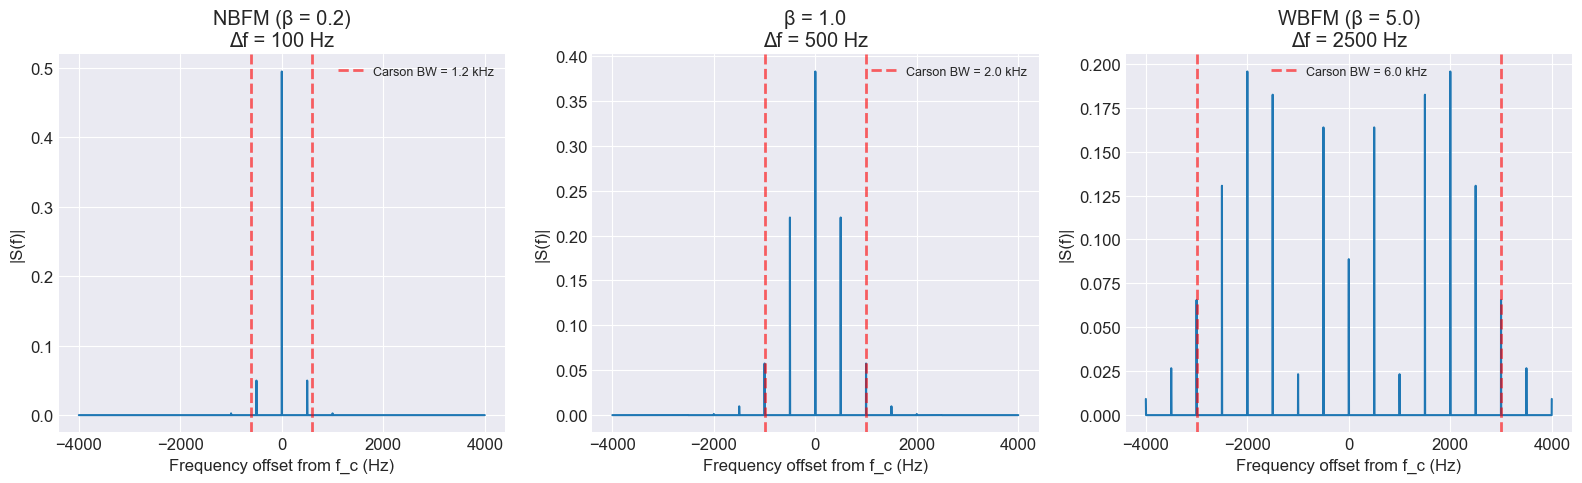

NBFM vs WBFM Bandwidth Comparison
Message: fm = 500 Hz
  beta  Delta_f (Hz)     Carson BW      Type
--------------------------------------------
   0.2           100        1200 Hz      NBFM
   1.0           500        2000 Hz      WBFM
   5.0          2500        6000 Hz      WBFM

Note: NBFM bandwidth ~ 2fm = 1000 Hz (like AM)
      WBFM bandwidth >> 2fm (trades BW for noise immunity)


In [6]:
# Part 5: NBFM vs WBFM - Spectrum Comparison

from scipy.fft import fft, fftfreq

fs = 200000
N = 200000  # samples
t = np.arange(N) / fs
fc = 10000  # 10 kHz carrier
fm = 500    # 500 Hz message

m = np.cos(2 * np.pi * fm * t)

beta_values = [0.2, 1.0, 5.0]
labels = ['NBFM (\u03b2 = 0.2)', '\u03b2 = 1.0', 'WBFM (\u03b2 = 5.0)']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (beta, label) in enumerate(zip(beta_values, labels)):
    kf = beta * fm  # Hz/V
    delta_f = kf
    phase = 2 * np.pi * kf * np.cumsum(m) / fs
    s_fm = np.cos(2 * np.pi * fc * t + phase)
    
    # Compute spectrum
    S = fft(s_fm * np.hanning(N)) / N
    freqs = fftfreq(N, 1/fs)
    
    # Plot positive frequencies near carrier
    mask = (freqs >= fc - 8*fm) & (freqs <= fc + 8*fm)
    ax = axes[i]
    ax.plot(freqs[mask] - fc, 2 * np.abs(S[mask]), linewidth=1.5)
    
    # Mark Carson's rule bandwidth
    bw_carson = 2 * (delta_f + fm)
    ax.axvline(x=bw_carson/2, color='r', linestyle='--', alpha=0.6,
               label=f'Carson BW = {bw_carson/1000:.1f} kHz')
    ax.axvline(x=-bw_carson/2, color='r', linestyle='--', alpha=0.6)
    
    ax.set_xlabel('Frequency offset from f_c (Hz)')
    ax.set_ylabel('|S(f)|')
    ax.set_title(f'{label}\n\u0394f = {delta_f:.0f} Hz')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print comparison
print("=" * 60)
print("NBFM vs WBFM Bandwidth Comparison")
print("=" * 60)
print(f"Message: fm = {fm} Hz")
print(f"{'beta':>6}  {'Delta_f (Hz)':>12}  {'Carson BW':>12}  {'Type':>8}")
print("-" * 44)
for beta in beta_values:
    delta_f = beta * fm
    bw = 2 * (delta_f + fm)
    typ = 'NBFM' if beta < 0.3 else 'WBFM'
    print(f"{beta:>6.1f}  {delta_f:>12.0f}  {bw:>10.0f} Hz  {typ:>8}")
print(f"\nNote: NBFM bandwidth ~ 2fm = {2*fm} Hz (like AM)")
print(f"      WBFM bandwidth >> 2fm (trades BW for noise immunity)")

## Summary

### Key Formulas

| Concept | Formula |
|---------|--------|
| FM signal | $s(t) = A_c \cos\left[2\pi f_c t + 2\pi k_f \int m(\tau) d\tau\right]$ |
| PM signal | $s(t) = A_c \cos[2\pi f_c t + k_p m(t)]$ |
| Instantaneous frequency | $f_i(t) = f_c + k_f m(t)$ |
| Frequency deviation | $\Delta f = k_f \cdot \max\lvert m(t) \rvert$ |
| Modulation index | $\beta = \Delta f / f_m$ |
| Carson's rule | $BW \approx 2(\Delta f + f_m) = 2(\beta + 1) f_m$ |

### FM vs PM

| Property | FM | PM |
|----------|-------|------|
| Phase varies with | $\int m(t)$ | $m(t)$ |
| Freq varies with | $m(t)$ | $dm/dt$ |
| Convert FM to PM | Differentiate $m(t)$ first | Direct |
| Convert PM to FM | Direct | Integrate $m(t)$ first |

### Key Takeaways
1. **FM and PM** are angle modulation: constant envelope, information in frequency/phase
2. **FM is PM** with the message integrated; PM is FM with message differentiated
3. **Modulation index** $\beta$ determines spectral width: NBFM ($\beta < 0.3$) vs WBFM ($\beta \gg 1$)
4. FM trades bandwidth for improved noise performance vs AM

### Next Topics
- **Lesson 11:** FM spectrum (Bessel functions), Carson's rule, Binary FSK